<a href="https://colab.research.google.com/github/emiliomartineziteso/sim-mat/blob/main/Tarea2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea - Caminata aleatoria y simulación de apuestas

#### 1. Simulación del movimiento browniano

El movimiento browniano es el movimiento aleatorio que se observa en las partículas que se hallan en un medio fluido, como resultado de choques contra las moléculas de dicho fluido [(referencia)].

[(referencia)]: https://es.wikipedia.org/wiki/Movimiento_browniano

Para simular el movimiento, en lugar de usar las ecuaciones integro-diferenciales que describe Einstein, use una caminta aleatoria para los tres ejes $x$, $y$, $z$ de la siguiente forma
$$
W_i=W_{i-1}+X_i\sqrt{\Delta t}
$$
donde, $\Delta t=0.001$ es un intervalo de tiempo y
$$
X_i=\left\{\begin{array}{l}
1\\
-1
\end{array}\right.,
$$
se escoge de forma aleatoria con la misma probabilidad.

Simule tres caminatas con $10$ segundos (10000 pasos) y represéntelo en un gráfico 3D.

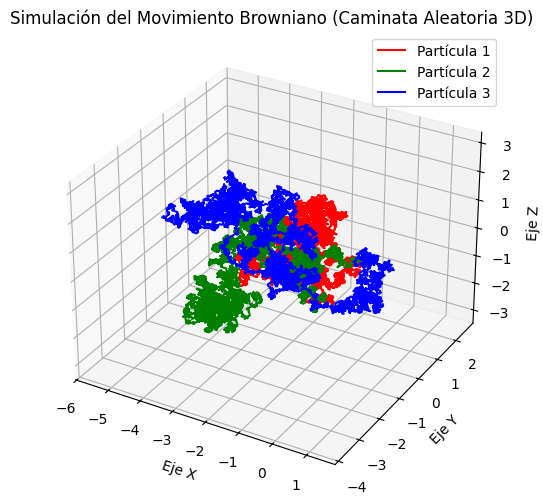

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# === Parámetros de la simulación ===
dt = 0.001       # Intervalo de tiempo
T = 10           # Tiempo total (segundos)
N = int(T / dt)  # Número de pasos
n_particulas = 3 # Número de caminatas


# Inicializamos posiciones
x = np.zeros((N, n_particulas))
y = np.zeros((N, n_particulas))
z = np.zeros((N, n_particulas))

for i in range(1, N):

    dx = np.random.choice([-1, 1], n_particulas) * np.sqrt(dt)
    dy = np.random.choice([-1, 1], n_particulas) * np.sqrt(dt)
    dz = np.random.choice([-1, 1], n_particulas) * np.sqrt(dt)


    x[i] = x[i-1] + dx
    y[i] = y[i-1] + dy
    z[i] = z[i-1] + dz

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

colores = ['r', 'g', 'b']
for j in range(n_particulas):
    ax.plot(x[:, j], y[:, j], z[:, j], color=colores[j], label=f'Partícula {j+1}')

ax.set_title('Simulación del Movimiento Browniano (Caminata Aleatoria 3D)')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Eje Z')
ax.legend()
plt.show()


Modifique la caminata anterior de tal forma que solo le regrese la última posición.

In [ ]:
import numpy as np

# === Parámetros ===
dt = 0.001       # Intervalo de tiempo
T = 10           # Tiempo total
N = int(T / dt)  # Número de pasos
n_particulas = 3 # Número de caminatas

# === Simulación ===
pos_final = np.zeros((n_particulas, 3))  # Guardará [x, y, z] finales

for j in range(n_particulas):
    x = 0
    y = 0
    z = 0
    for i in range(1, N):
        dx = np.random.choice([-1, 1]) * np.sqrt(dt)
        dy = np.random.choice([-1, 1]) * np.sqrt(dt)
        dz = np.random.choice([-1, 1]) * np.sqrt(dt)

        x += dx
        y += dy
        z += dz

    pos_final[j] = [x, y, z]

# === Resultado ===
for i, (x, y, z) in enumerate(pos_final, start=1):
    print(f"Última posición de la partícula {i}: x={x:.4f}, y={y:.4f}, z={z:.4f}")


Última posición de la partícula 1: x=-2.4350, y=-0.9803, z=-4.3956
Última posición de la partícula 2: x=-2.5614, y=0.3479, z=-2.0555
Última posición de la partícula 3: x=-0.9171, y=3.8896, z=0.9171


Simule 1000 caminatas con este nuevo modelo de movimiento browniano y diga la probabilidad de que las partículas satisfagan $x>1$, $y>2$ y $z>0$.

In [ ]:
import numpy as np


dt = 0.001       # Intervalo de tiempo
T = 10           # Tiempo total
N = int(T / dt)  # Número de pasos
n_caminatas = 1000  # Número de simulaciones


pos_final = np.zeros((n_caminatas, 3))  # Guardará [x, y, z] finales

for j in range(n_caminatas):
    # Generar los pasos aleatorios de una caminata
    dx = np.random.choice([-1, 1], N) * np.sqrt(dt)
    dy = np.random.choice([-1, 1], N) * np.sqrt(dt)
    dz = np.random.choice([-1, 1], N) * np.sqrt(dt)

    # Posición final = suma de los desplazamientos
    x = np.sum(dx)
    y = np.sum(dy)
    z = np.sum(dz)

    pos_final[j] = [x, y, z]

# === Cálculo de probabilidad ===
condicion = (pos_final[:, 0] > 1) & (pos_final[:, 1] > 2) & (pos_final[:, 2] > 0)
probabilidad = np.mean(condicion)

print(f"Probabilidad de que x>1, y>2 y z>0: {probabilidad:.5f}")


Probabilidad de que x>1, y>2 y z>0: 0.04400


#### 2. Apuesta arriesgada

Un jugador, con 20 pesos de capital inicial, decide apostar a un volado (con una moneda perfectamente nivelada) la mitad de su capital si éste es mayor o igual a 6 pesos, de lo contrario, solo 2. Esto es, el capital $C_i$ en cada volado $V_i$ se describe como
$$
C_{i+1}=C_i+V_iA_i
$$
donde la apuesta es
$$
A_i=\left\{\begin{array}{l}
C_i/2,\quad \mbox{si }C_i\geq 6\\
2,\quad \mbox{de lo contrario.}
\end{array}\right.
$$

1. Grafique la evolución del capital hasta quedar en cero.

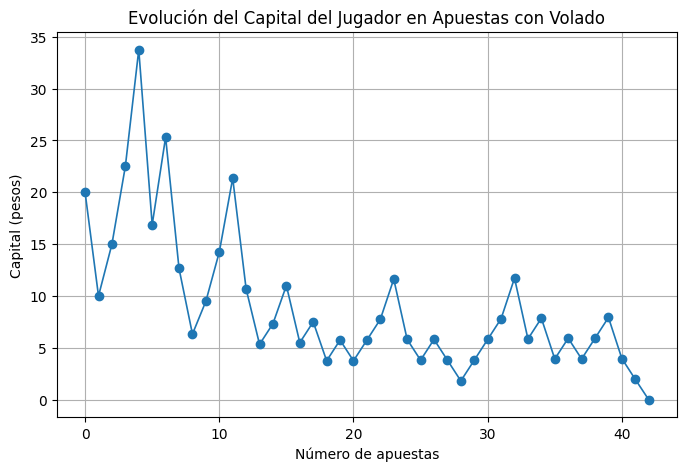

Número total de apuestas: 42
Capital final: 0 pesos


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === Parámetros iniciales ===
capital_inicial = 20
capital = [capital_inicial]

# === Simulación ===
while capital[-1] > 0:
    C = capital[-1]
    # Determinar apuesta según la regla
    A = C / 2 if C >= 6 else 2

    # Volado: +1 (gana) o -1 (pierde)
    V = np.random.choice([-1, 1])

    # Nuevo capital
    nuevo_C = C + V * A
    nuevo_C = max(nuevo_C, 0)

    # Guardar
    capital.append(nuevo_C)


plt.figure(figsize=(8,5))
plt.plot(capital, marker='o', linewidth=1.2)
plt.title('Evolución del Capital del Jugador en Apuestas con Volado')
plt.xlabel('Número de apuestas')
plt.ylabel('Capital (pesos)')
plt.grid(True)
plt.show()

print(f"Número total de apuestas: {len(capital)-1}")
print(f"Capital final: {capital[-1]} pesos")


2. Determine el número de volados promedio para quedar en quiebra usando la simulación montecarlo para 10,000 apostadores.

=== RESULTADOS DE LA SIMULACIÓN MONTE CARLO ===
Apostadores simulados: 10000
Promedio de volados hasta quiebra: 24.74
Mediana: 19.00
Desviación estándar: 20.07


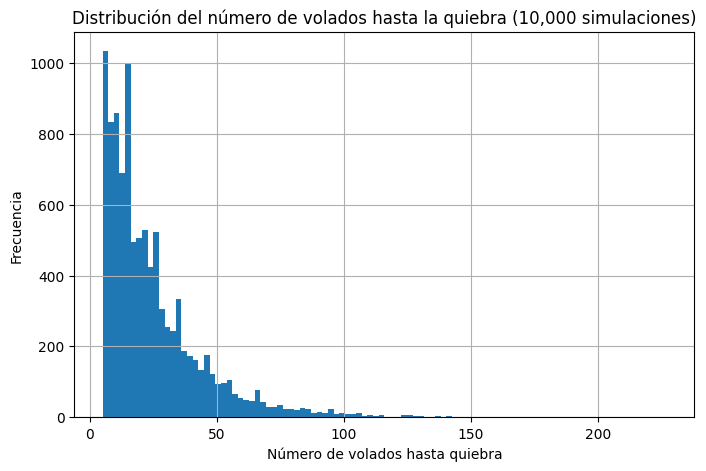

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === Parámetros ===
np.random.seed(42)      # Semilla para reproducibilidad
n_sim = 10_000          # Número de apostadores
capital_inicial = 20.0  # Capital inicial (pesos)
max_steps = 1_000_000   # Límite de seguridad (por si una simulación se alarga mucho)

# === Simulación Monte Carlo ===
resultados = np.zeros(n_sim, dtype=int)

for i in range(n_sim):
    C = capital_inicial
    pasos = 0
    while C > 0 and pasos < max_steps:
        # Regla de apuesta
        if C >= 6:
            A = C / 2
        elif C >= 2:
            A = 2
        else:
            A = C  # Si el capital es menor a 2, apuesta todo

        # Volado: gana (+1) o pierde (-1)
        V = np.random.choice([-1, 1])

        # Actualizar capital
        C = C + V * A
        if C < 0:
            C = 0
        pasos += 1

    resultados[i] = pasos

# === Resultados ===
promedio = np.mean(resultados)
mediana = np.median(resultados)
desv_std = np.std(resultados, ddof=1)

print("=== RESULTADOS DE LA SIMULACIÓN MONTE CARLO ===")
print(f"Apostadores simulados: {n_sim}")
print(f"Promedio de volados hasta quiebra: {promedio:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación estándar: {desv_std:.2f}")

# === Histograma de resultados ===
plt.figure(figsize=(8,5))
plt.hist(resultados, bins=100)
plt.title("Distribución del número de volados hasta la quiebra (10,000 simulaciones)")
plt.xlabel("Número de volados hasta quiebra")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()


3. Muestre un histograma del número de volados.